# KNN and Radius Neighbors Classification Using the Wine Dataset

**Name:** Elkana Munganga  
**Course:** MSCS-634-M50 – Advanced Big Data and Data Mining  
**Assignment:** KNN and Radius Neighbors Classification Lab

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Imports successful!")

Imports successful!


In [11]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")

df = X.copy()
df["class"] = y

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nClass Distribution:")
print(y.value_counts().sort_index())

print("\nClass Names:")
for i, name in enumerate(wine.target_names):
    print(i, "=", name)

Dataset Shape: (178, 14)

First 5 Rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Class Distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64

Class Names:
0 = class_0
1 = class_1
2 = class_2


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining percentage:", round(len(X_train) / len(X) * 100, 2), "%")
print("Testing percentage:", round(len(X_test) / len(X) * 100, 2), "%")

Total samples: 178
Training samples: 142
Testing samples: 36

Training percentage: 79.78 %
Testing percentage: 20.22 %


In [13]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    knn_accuracies.append(accuracy)

knn_results = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": knn_accuracies
})

knn_results

,K Value,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


### KNN Results
I tested the KNN classifier using k values of 1, 5, 11, 15, and 21. The results show how changing the number of nearest neighbors affects the classification accuracy of the model.

In [14]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for radius in radius_values:
    rnn = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label="most_frequent"
    )

    rnn.fit(X_train, y_train)

    predictions = rnn.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    rnn_accuracies.append(accuracy)

rnn_results = pd.DataFrame({
    "Radius": radius_values,
    "Accuracy": rnn_accuracies
})

rnn_results

,Radius,Accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


### RNN Results
I tested the Radius Neighbors classifier using radius values of 350, 400, 450, 500, 550, and 600. The results show how changing the neighborhood radius affects the classification accuracy.

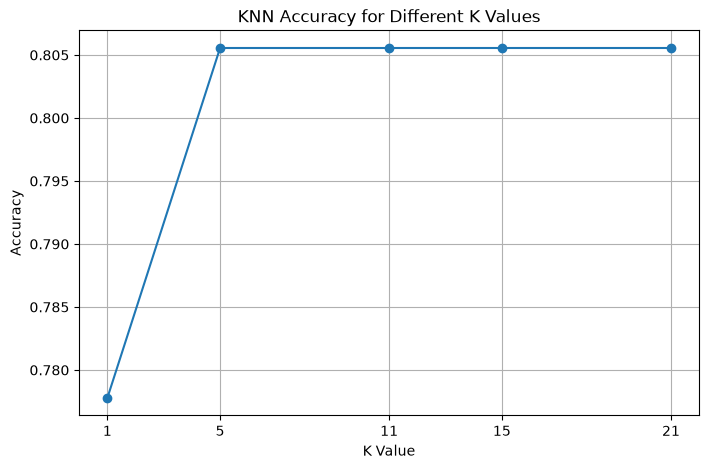

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_accuracies, marker="o")

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

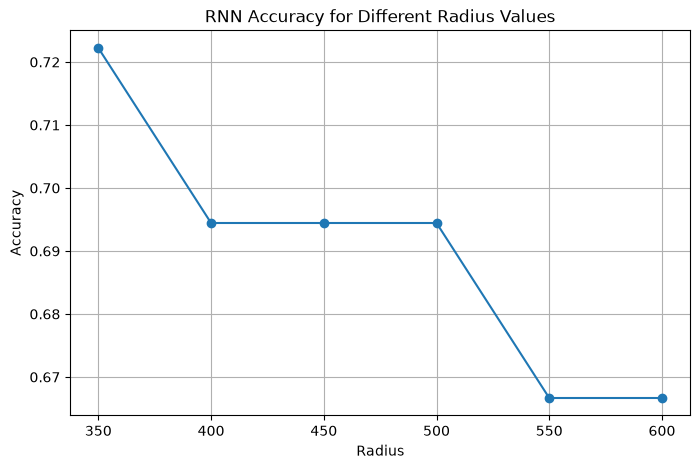

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(radius_values, rnn_accuracies, marker="o")

plt.title("RNN Accuracy for Different Radius Values")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.xticks(radius_values)
plt.grid(True)

plt.show()

In [17]:
best_k_index = knn_accuracies.index(max(knn_accuracies))
best_radius_index = rnn_accuracies.index(max(rnn_accuracies))

print("Best KNN:")
print("K =", k_values[best_k_index])
print("Accuracy =", round(knn_accuracies[best_k_index], 4))

print("\nBest RNN:")
print("Radius =", radius_values[best_radius_index])
print("Accuracy =", round(rnn_accuracies[best_radius_index], 4))

Best KNN:
K = 5
Accuracy = 0.8056

Best RNN:
Radius = 350
Accuracy = 0.7222


### Model Comparison and Observations

The results show that the performance of both KNN and RNN changes depending on the parameter selected. For KNN, changing k determines how many nearby observations are considered when classifying a new sample. For RNN, changing the radius determines how large of an area is considered when finding neighboring observations.

Based on my results, some parameter values produced better accuracy than others, showing that selecting the appropriate k or radius can have an important effect on model performance.

KNN may be preferable when I want to classify observations using a fixed number of nearest neighbors. RNN may be more useful when I want the number of neighbors to depend on how many observations exist within a specific distance. The results demonstrate that testing different parameter values is important when selecting a model.